# Week 5

## Objective

This notebook documents the Week 5 backtesting framework and summarizes the implementation,
turnover, transaction-cost, liquidity, and capacity analysis.

The notebook evaluates both monthly and quarterly rebalancing.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.strategies import load_panel, prepare_strategies
from src.task2_analysis import run_task2
from src.task3_analysis import run_task3
from src.task4_analysis import run_task4

In [2]:
df = load_panel("panel.csv")

print("Shape:", df.shape)
print("Number of stocks:", df["Ticker"].nunique())
print("Start date:", df["Date"].min())
print("End date:", df["Date"].max())

df.head()

Shape: (48578, 26)
Number of stocks: 607
Start date: 2018-02-28 00:00:00
End date: 2024-12-31 00:00:00


,Date,Ticker,Return,Industry_x,E,S,G,ESG,ESG_z,E_z,...,Sector,Industry_y,Size,Value_PB,Value_PE,ESG_sector,ESG_minus_sector,ESG_sector_z,ESG_pred,ESG_ortho
0,2018-02-28,A,-0.065913,Life Sciences Tools and Services,573,231,233,1037,0.232521,1.11077,...,Healthcare,Diagnostics & Research,24.372118,0.185463,0.036599,109.037037,109.037037,0.522551,0.198103,0.034417
1,2018-03-31,A,-0.024639,Life Sciences Tools and Services,573,231,233,1037,0.232521,1.11077,...,Healthcare,Diagnostics & Research,24.372118,0.185463,0.036599,109.037037,109.037037,0.522551,0.198103,0.034417
2,2018-04-30,A,-0.015146,Life Sciences Tools and Services,573,231,233,1037,0.232521,1.11077,...,Healthcare,Diagnostics & Research,24.372118,0.185463,0.036599,109.037037,109.037037,0.522551,0.198103,0.034417
3,2018-05-31,A,-0.058108,Life Sciences Tools and Services,573,231,233,1037,0.232521,1.11077,...,Healthcare,Diagnostics & Research,24.372118,0.185463,0.036599,109.037037,109.037037,0.522551,0.198103,0.034417
4,2018-06-30,A,-0.001292,Life Sciences Tools and Services,573,231,233,1037,0.232521,1.11077,...,Healthcare,Diagnostics & Research,24.372118,0.185463,0.036599,109.037037,109.037037,0.522551,0.198103,0.034417


## Strategy Construction

### Value

The value strategy uses P/E as the primary valuation signal.

### Momentum

The momentum strategy uses 12–1 month momentum, meaning the cumulative
return over the previous 12 months excluding the most recent month.

### Combined

The combined strategy combines the value and momentum signals.

In [3]:
strategies = prepare_strategies(df)

print(strategies.keys())
print("Value weights:")
print(strategies["value_weights"].head())

print("\nMomentum weights:")
print(strategies["momentum_weights"].head())

print("\nCombined weights:")
print(strategies["combined_weights"].head())

dict_keys(['data', 'value_weights', 'momentum_weights', 'combined_weights'])
Value weights:
Ticker        A  AACG  AAL      AAME  AAOI  AAON  AAP  AAPL      AATC  ABBV  \
Date                                                                          
2018-02-28  0.0   0.0  0.0  0.010638   0.0   0.0  0.0   0.0  0.010638   0.0   
2018-03-31  0.0   0.0  0.0  0.010638   0.0   0.0  0.0   0.0  0.010638   0.0   
2018-04-30  0.0   0.0  0.0  0.010638   0.0   0.0  0.0   0.0  0.010638   0.0   
2018-05-31  0.0   0.0  0.0  0.010638   0.0   0.0  0.0   0.0  0.010638   0.0   
2018-06-30  0.0   0.0  0.0  0.010638   0.0   0.0  0.0   0.0  0.010638   0.0   

Ticker      ...  YUM  YUMC  ZBH  ZBRA  ZEPP  ZIM      ZION       ZTS  ZWS  \
Date        ...                                                             
2018-02-28  ...  0.0   0.0  0.0   0.0   0.0  0.0  0.010638  0.010638  0.0   
2018-03-31  ...  0.0   0.0  0.0   0.0   0.0  0.0  0.010638  0.010638  0.0   
2018-04-30  ...  0.0   0.0  0.0   0.0   0.0  0

## Backtest Methodology

The backtest engine translates target portfolio weights into holdings,
trades, portfolio returns, and diagnostics.


- portfolio holdings and weights are tracked through time;
- turnover is measured from actual position changes;
- cash is tracked explicitly;
- missing securities and changing investable universes are handled by the engine.

The backtest was independently reconciled against an equal-weight benchmark.

In [4]:
task2 = run_task2("panel.csv")

print("Task 2 completed.")

Task 2 completed.


## Turnover Analysis

Turnover measures how much of the portfolio changes at each rebalance date.

One-way turnover is defined as the total absolute value of position changes
relative to portfolio value.

Two-way turnover is twice the one-way measure.

Monthly and quarterly rebalancing are compared for Value, Momentum, and Combined strategies.

In [5]:
turnover_summary = task2["summary"]

turnover_summary

turnover_summary[
    [
        "strategy",
        "frequency",
        "average_one_way_turnover",
        "average_two_way_turnover",
        "number_of_rebalances",
    ]
]

,strategy,frequency,average_one_way_turnover,average_two_way_turnover,number_of_rebalances
0,Value,monthly,0.082872,0.165744,83
1,Value,quarterly,0.158667,0.317334,28
2,Momentum,monthly,0.519183,1.038365,83
3,Momentum,quarterly,0.875752,1.751504,28
4,Combined,monthly,0.522232,1.044465,83
5,Combined,quarterly,0.870019,1.740038,28


### Turnover Findings

Value has substantially lower turnover than Momentum and Combined strategies.

Momentum and Combined experience much larger position changes, which makes them more sensitive to transaction costs.

## Transaction Costs

The transaction-cost framework considers multiple sources of implementation cost:

- fixed basis-point costs;
- bid-ask spread proxy;
- volume-based costs;
- additional slippage for less liquid securities.

Gross returns represent strategy performance before transaction costs.

Net returns subtract estimated trading costs from the gross strategy returns.

In [6]:
task3 = run_task3()

print("Task 3 completed.")

cost_summary = pd.read_csv("task3_cost_sensitivity.csv")

cost_summary

Task 3 completed.


,strategy,frequency,gross_return,fixed_net_return,spread_net_return,volume_net_return,slippage_net_return,full_cost_net_return,full_cost_drag,number_of_periods
0,Value,monthly,0.813510,0.801241,0.789053,0.813505,0.799599,0.763417,0.028039,83
1,Value,quarterly,0.780501,0.773012,0.765552,0.780498,0.772177,0.750015,0.017541,83
2,Momentum,monthly,1.173593,1.096598,1.022291,1.173573,1.110254,0.894794,0.138261,83
3,Momentum,quarterly,1.082819,1.041752,1.001460,1.082809,1.049626,0.931111,0.076442,83
4,Combined,monthly,1.429596,1.343188,1.259808,1.429589,1.364010,1.121320,0.136889,83
5,Combined,quarterly,1.515474,1.466435,1.418309,1.515468,1.478567,1.336456,0.074970,83


## Gross versus Net Performance

The transaction-cost analysis shows that the impact of implementation costs varies substantially across strategies.

Value is relatively cost-insensitive because of its lower turnover.

Momentum and Combined have substantially larger cost drag.

In [7]:
summary = pd.read_csv("backtest_summary.csv")

summary

display(
    summary[
        [
            "strategy",
            "frequency",
            "gross_return",
            "net_return",
            "cost_drag",
            "one_way_turnover",
            "two_way_turnover",
        ]
    ]
)

,strategy,frequency,gross_return,net_return,cost_drag,one_way_turnover,two_way_turnover
0,Value,monthly,0.813510,0.763417,0.050092,0.082872,0.165744
1,Value,quarterly,0.780501,0.750015,0.030486,0.158667,0.317334
2,Momentum,monthly,1.173593,0.894794,0.278799,0.519183,1.038365
3,Momentum,quarterly,1.082819,0.931111,0.151708,0.875752,1.751504
4,Combined,monthly,1.429596,1.121320,0.308276,0.522232,1.044465
5,Combined,quarterly,1.515474,1.336456,0.179018,0.870019,1.740038


## Liquidity and Capacity

In [8]:
liquidity_comparison = pd.read_csv(
    "task4_liquidity_comparison.csv"
)

liquidity_comparison

,strategy,before_filter,after_filter,change
0,value,0.768922,0.776768,0.007847
1,momentum,1.424304,1.459761,0.035457
2,combined,1.612590,1.147915,-0.464675


### Liquidity Findings

Liquidity filtering can change strategy performance.

In the current analysis:

- Value performance changes only modestly after filtering;
- Momentum performance increases after filtering;
- Combined performance declines substantially after filtering.

This demonstrates the trade-off between historical alpha and practical implementability.

## Backtest Result Charts

The following chart pack summarizes:

1. cumulative returns;
2. drawdowns;
3. rolling Sharpe ratios;
4. turnover;
5. gross versus net performance.

charts/cumulative_returns.png


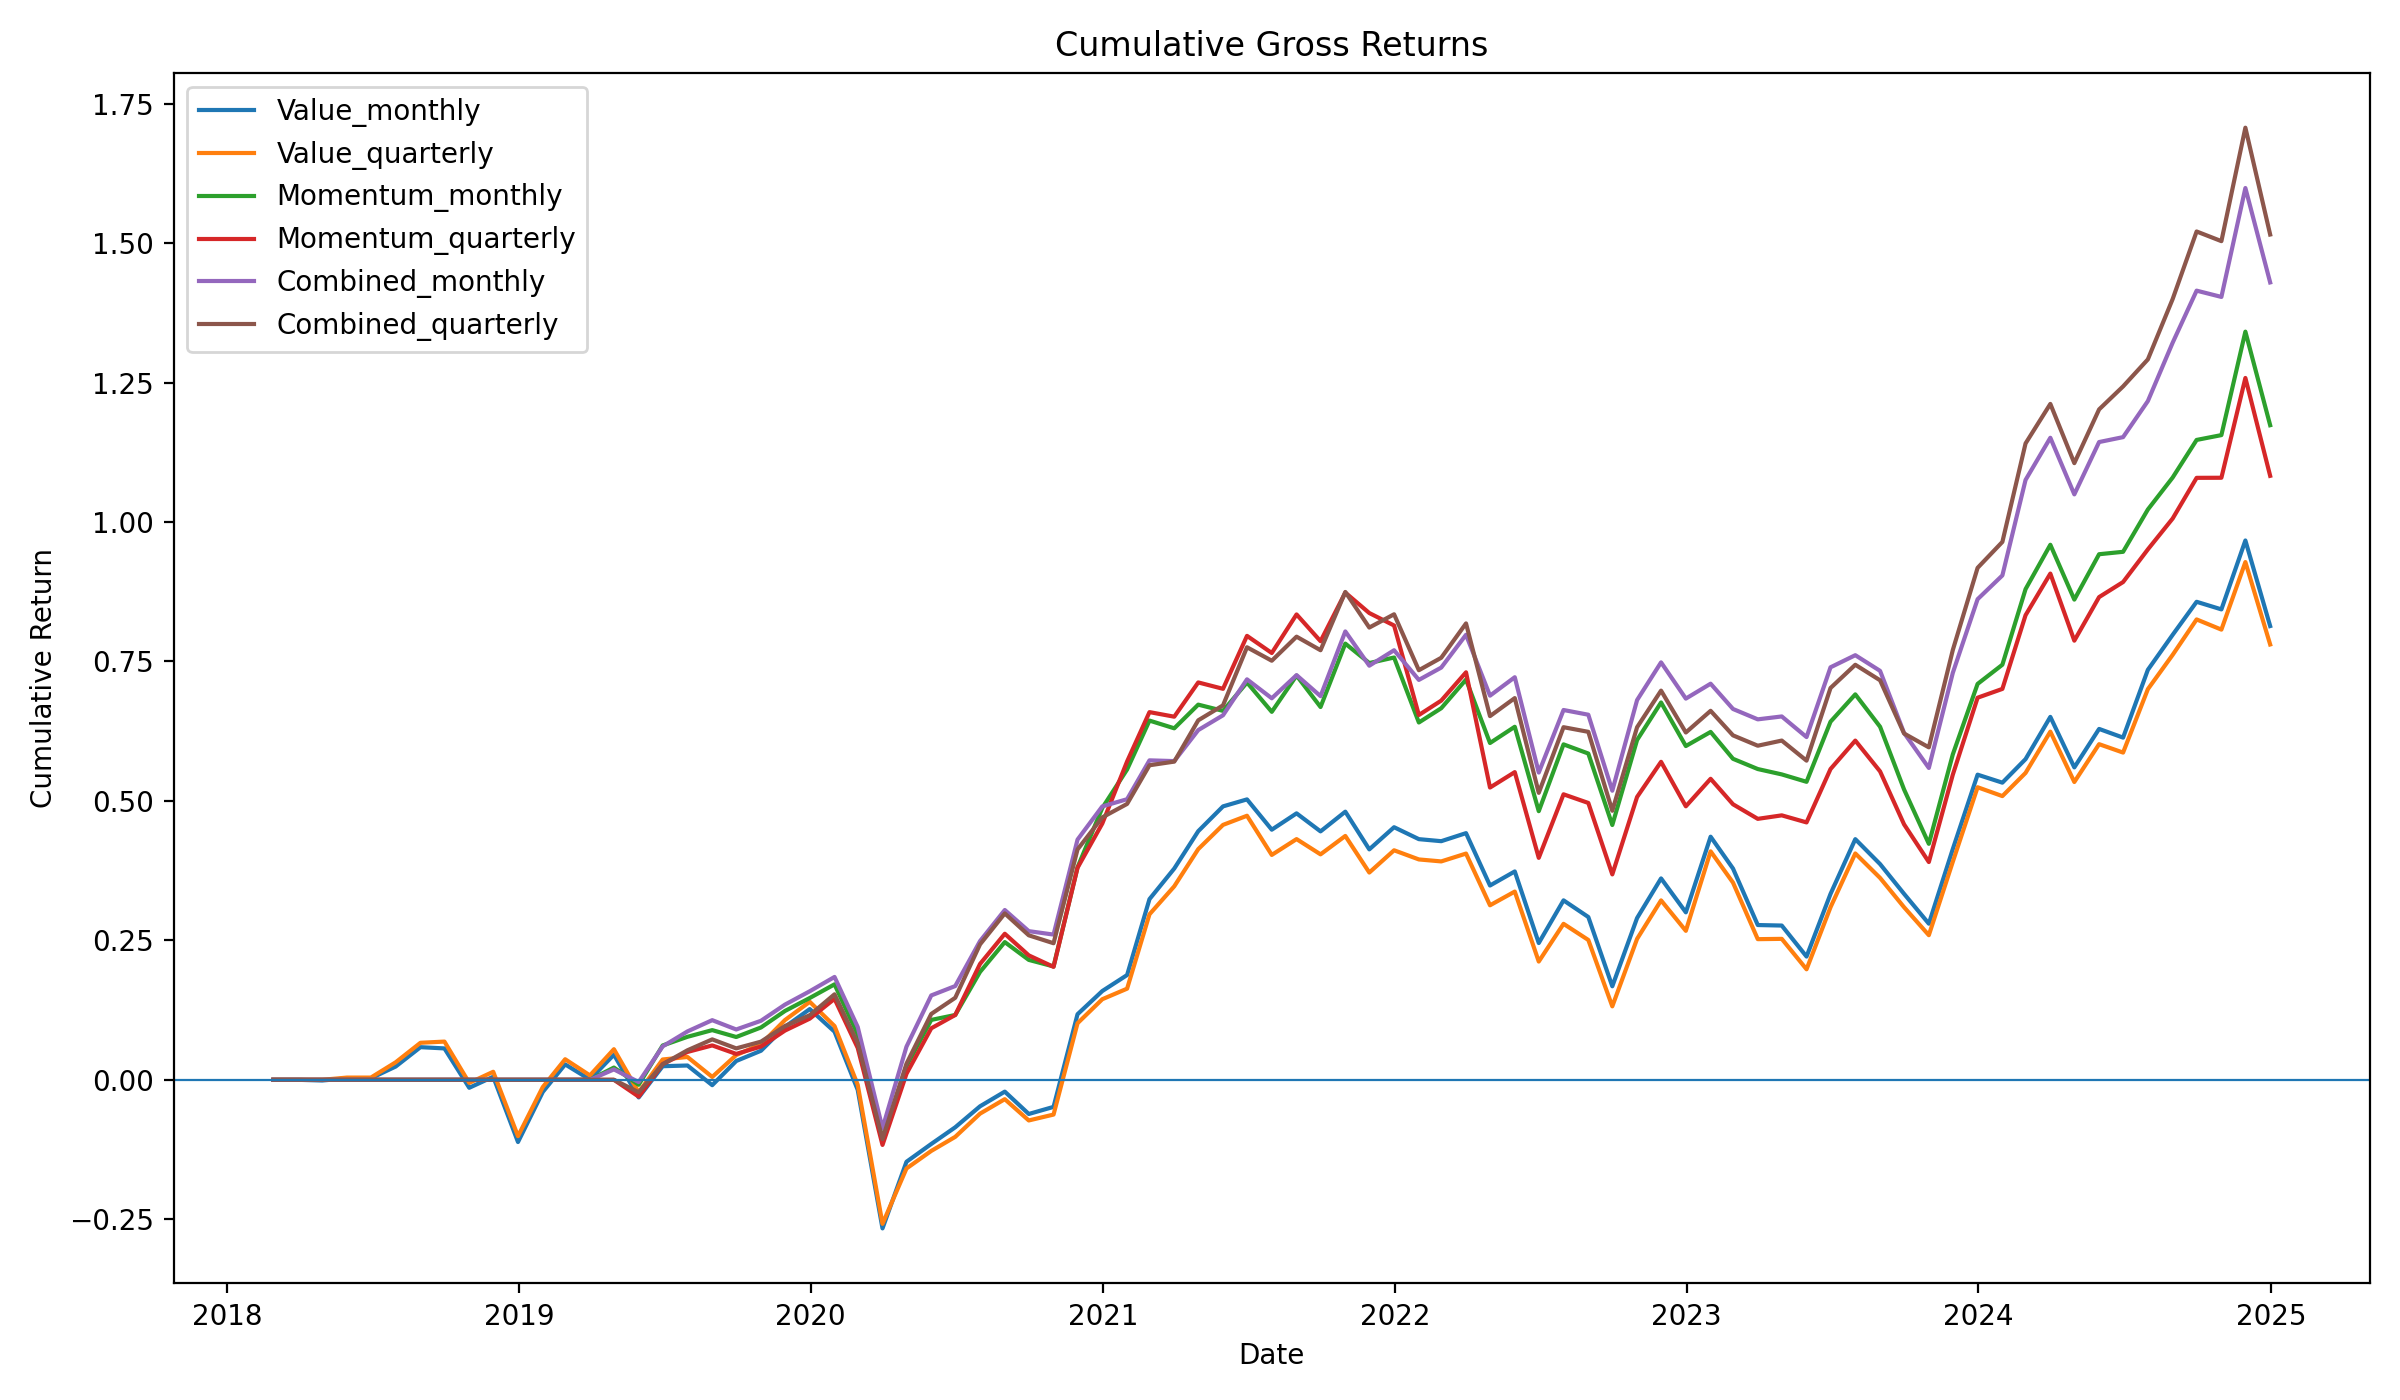

charts/drawdowns.png


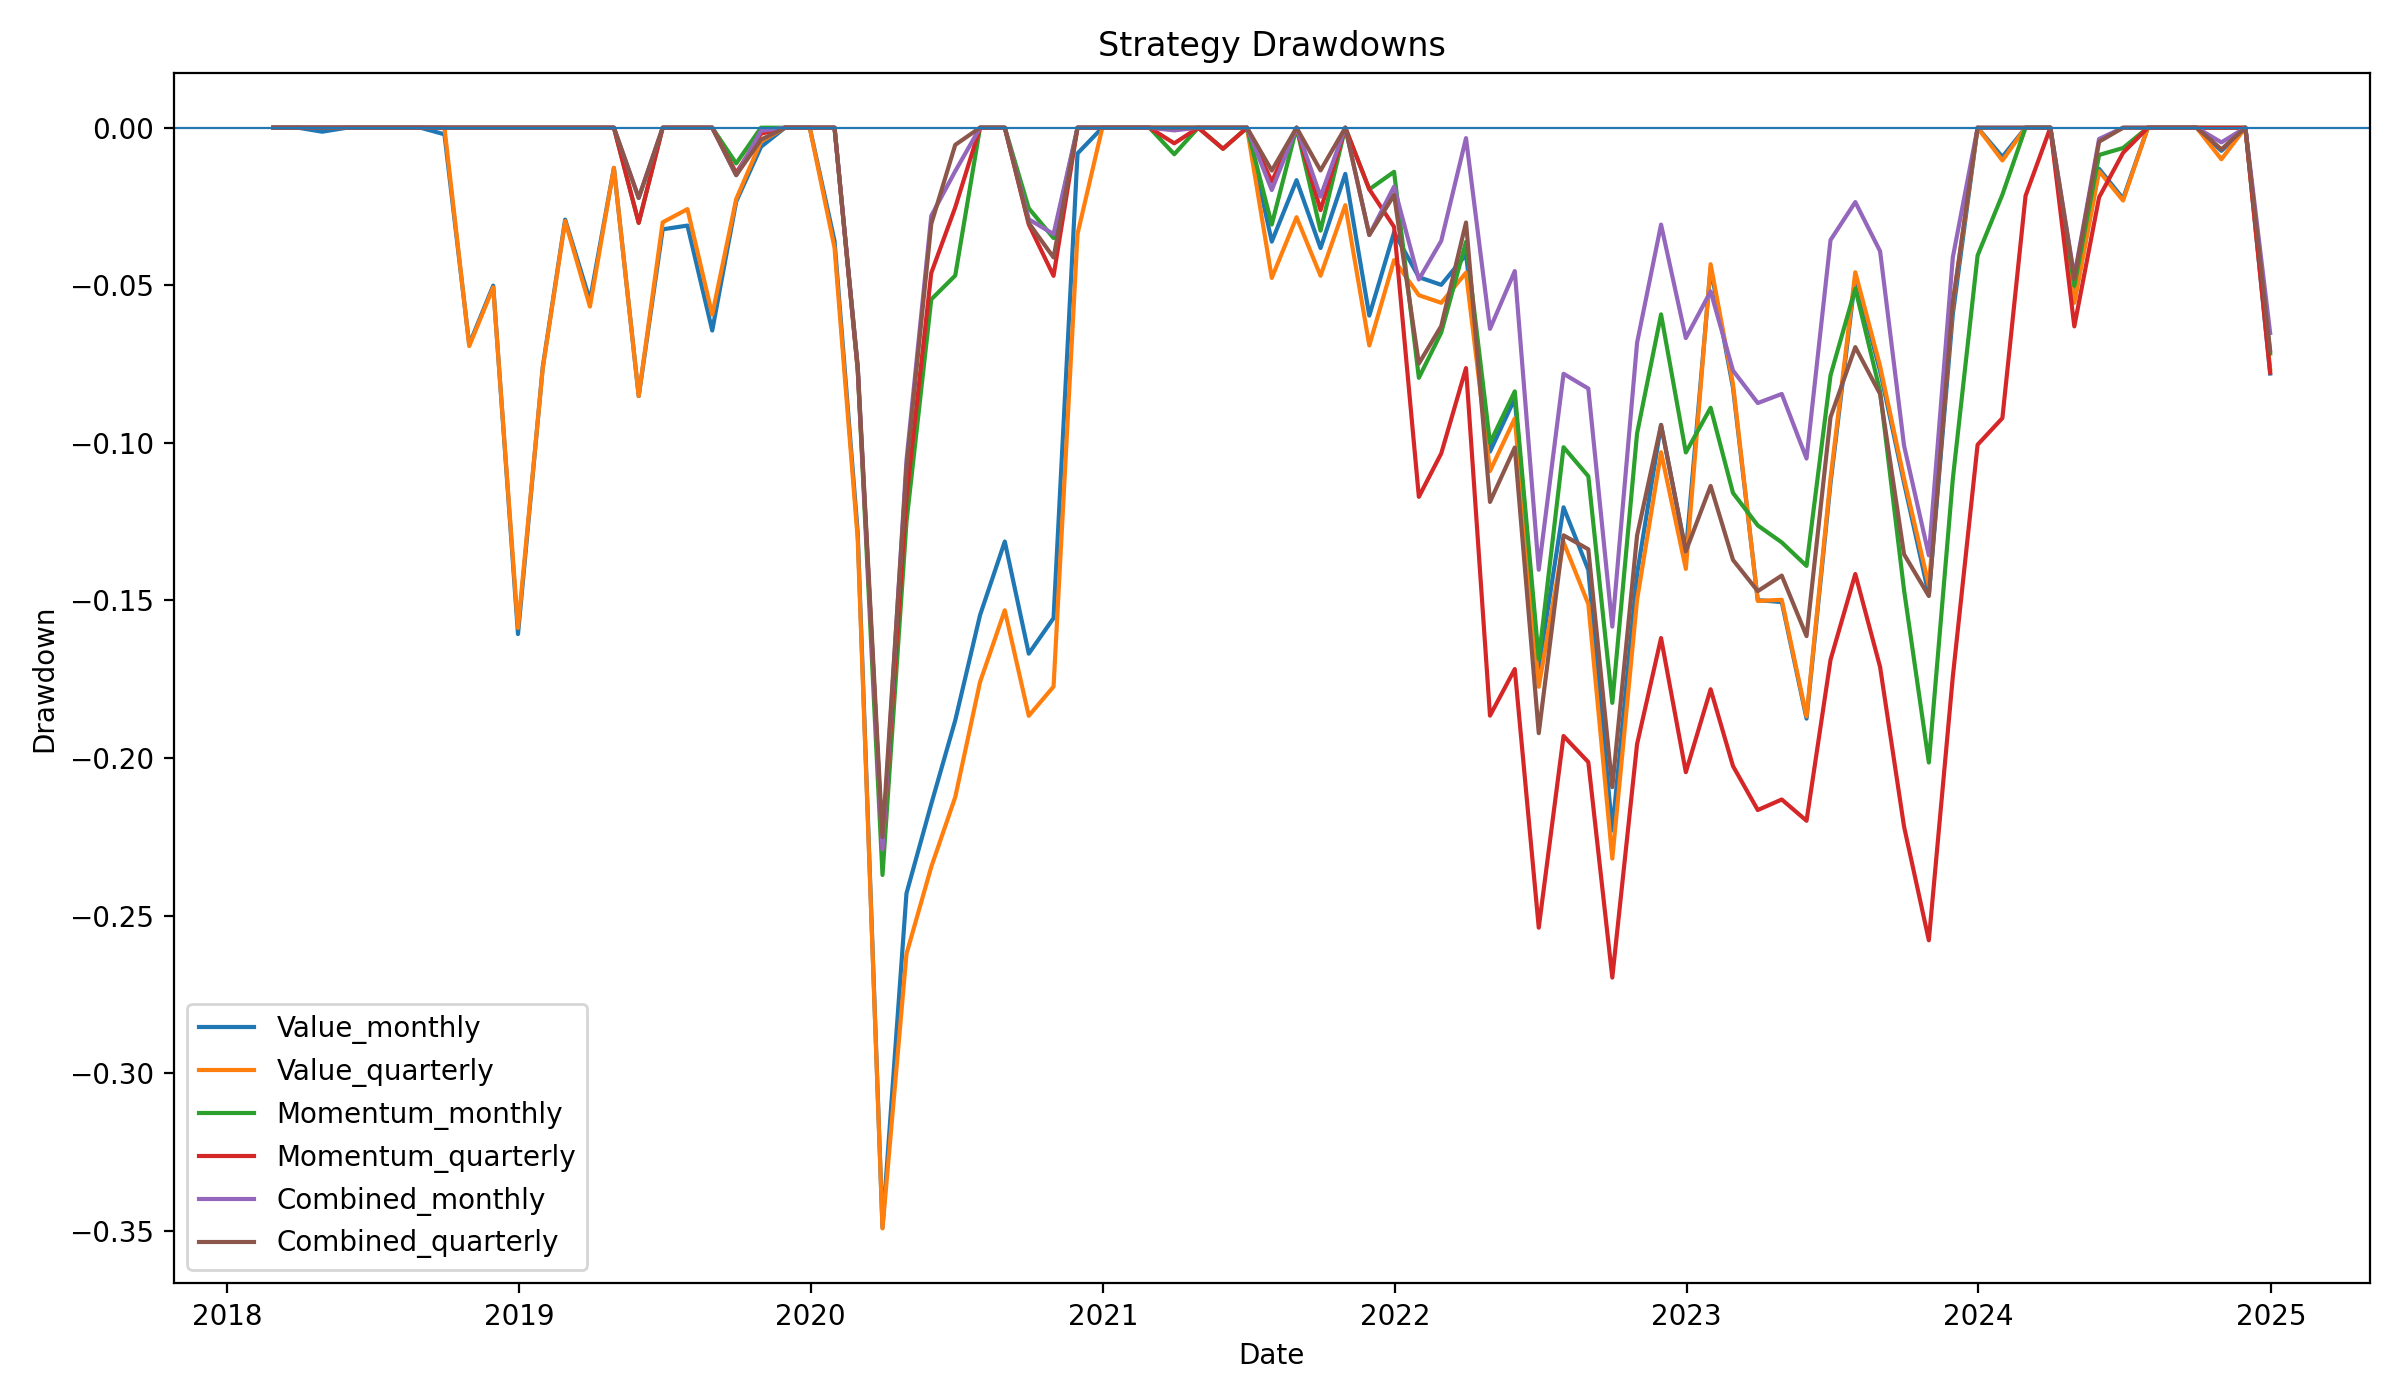

charts/rolling_sharpe.png


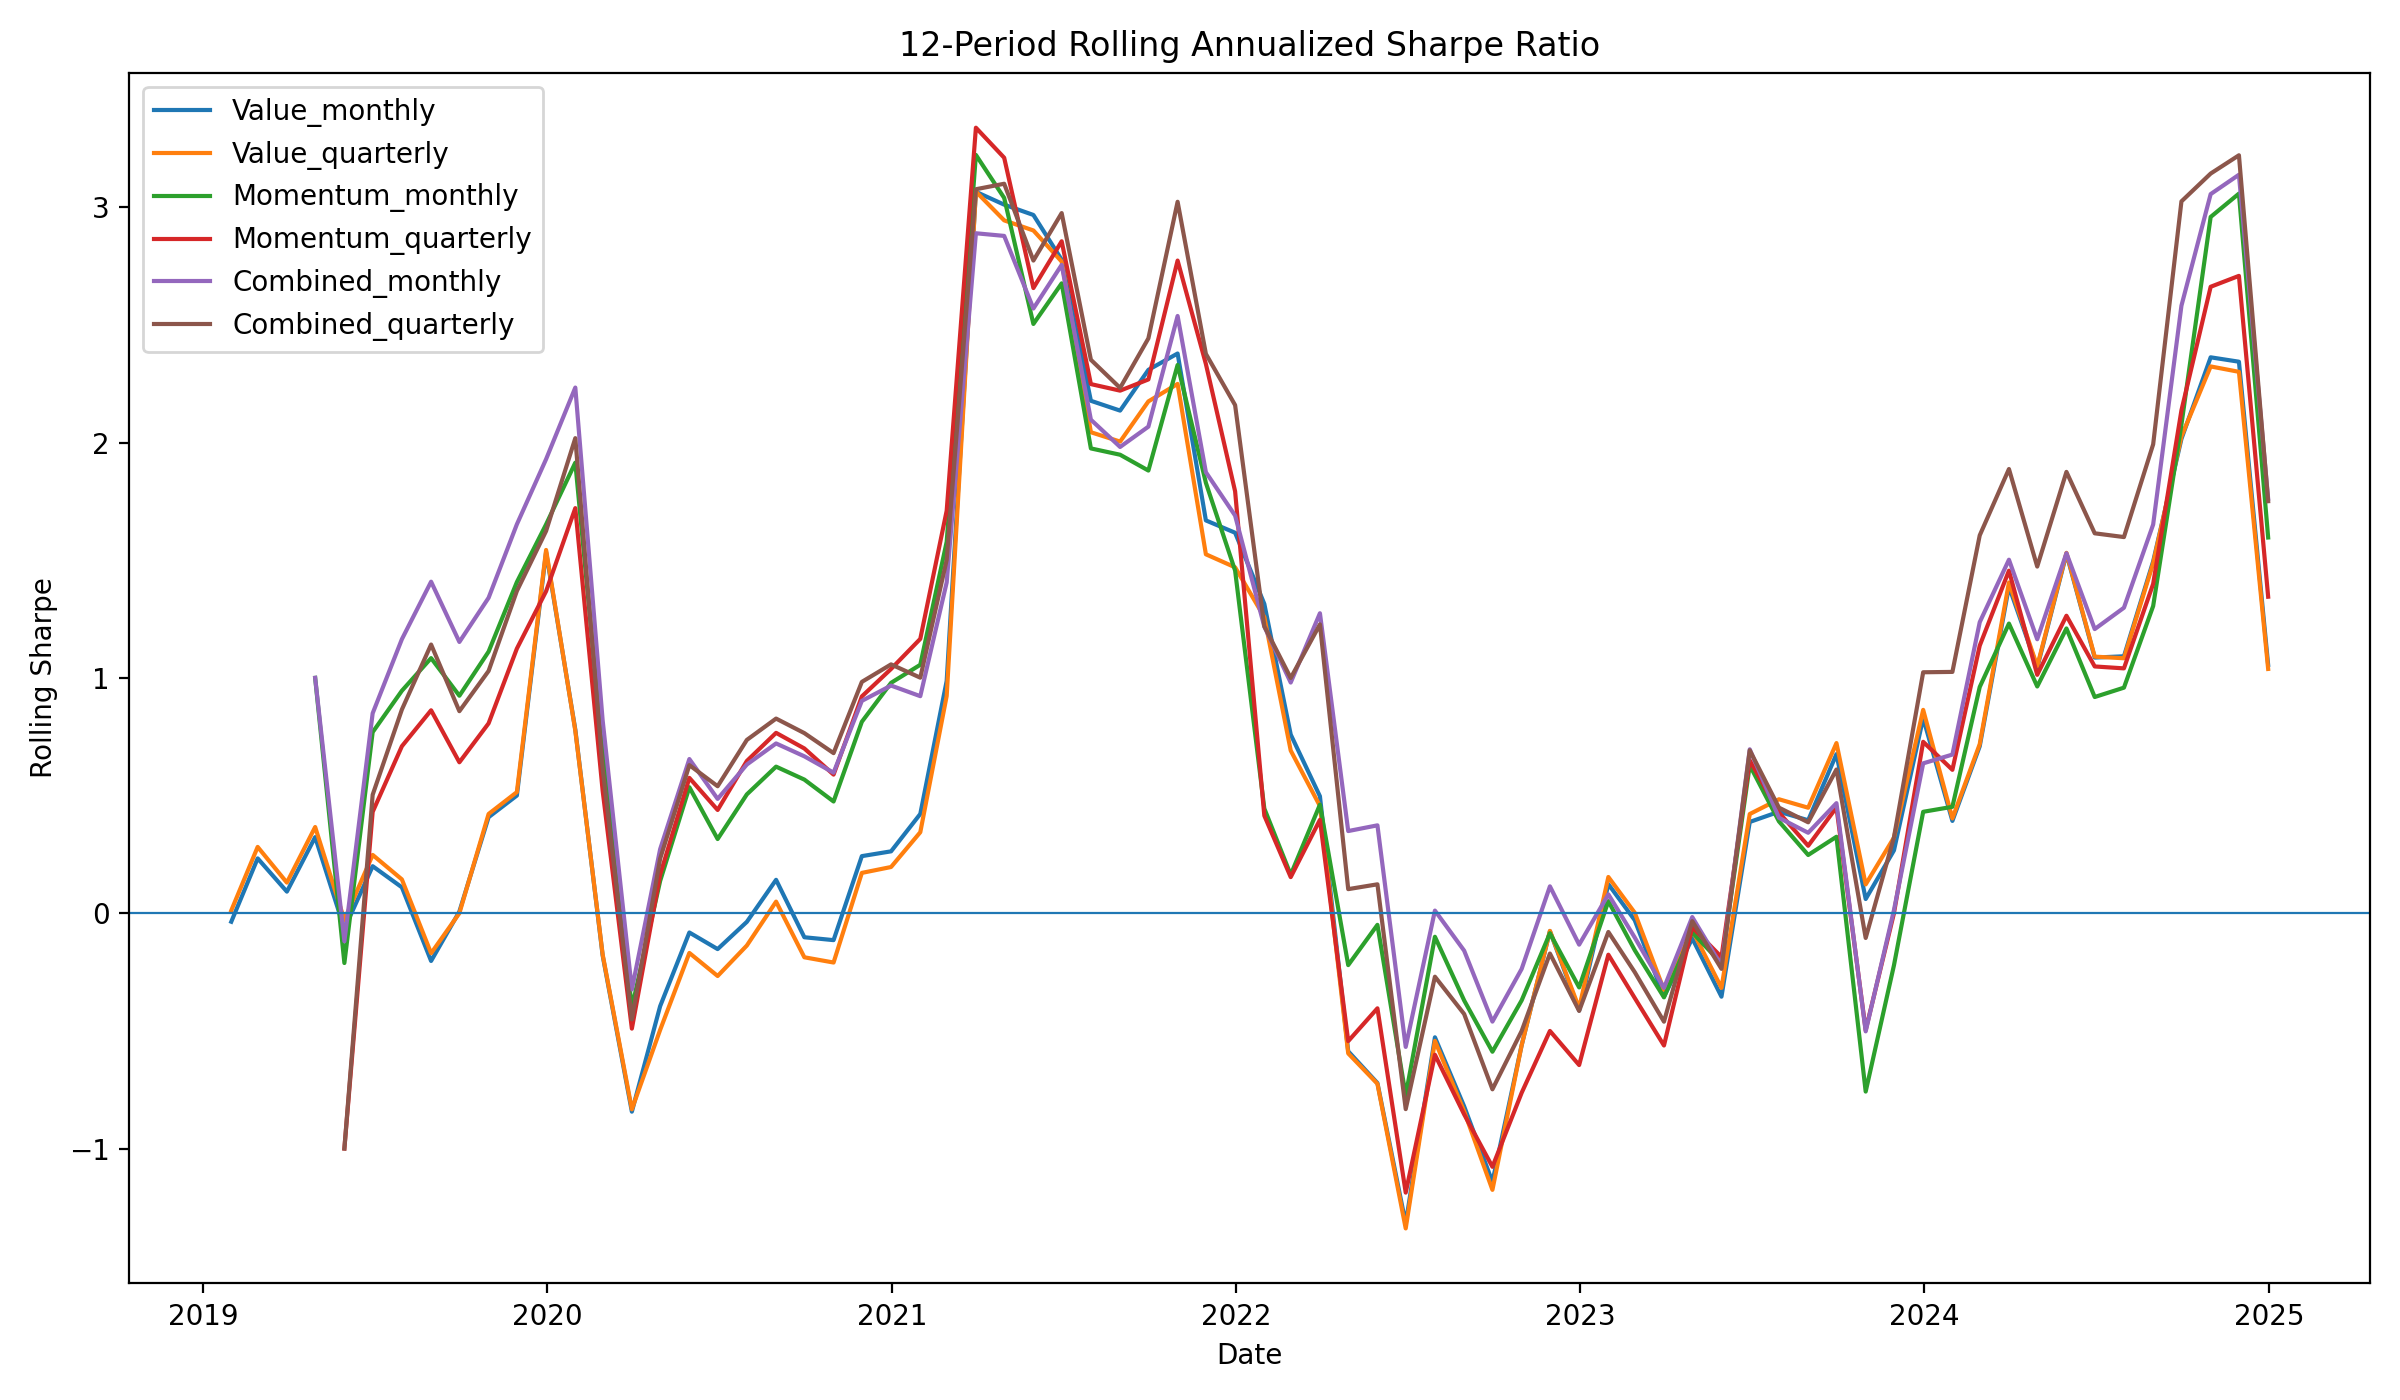

charts/turnover.png


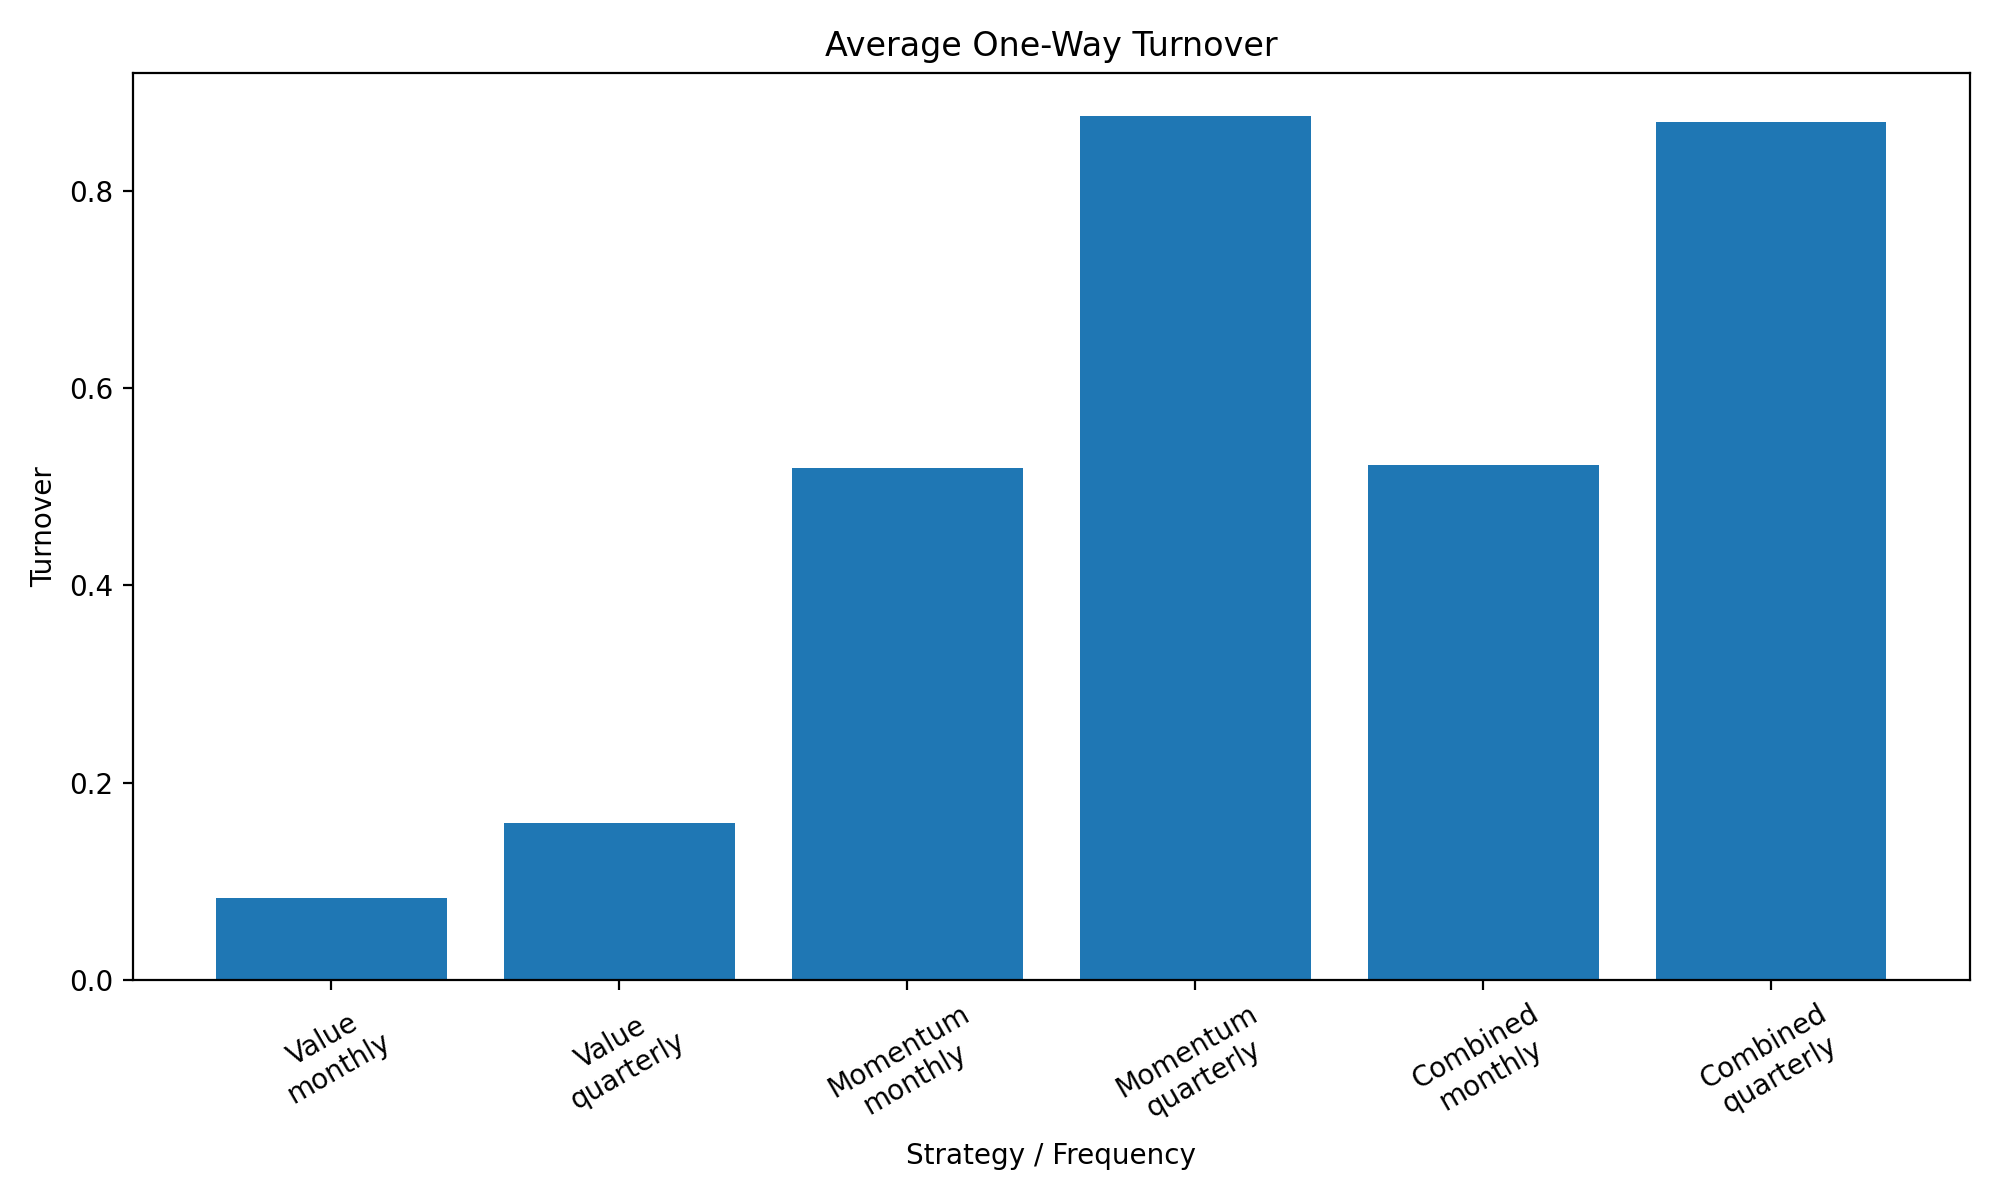

charts/cost_drag.png


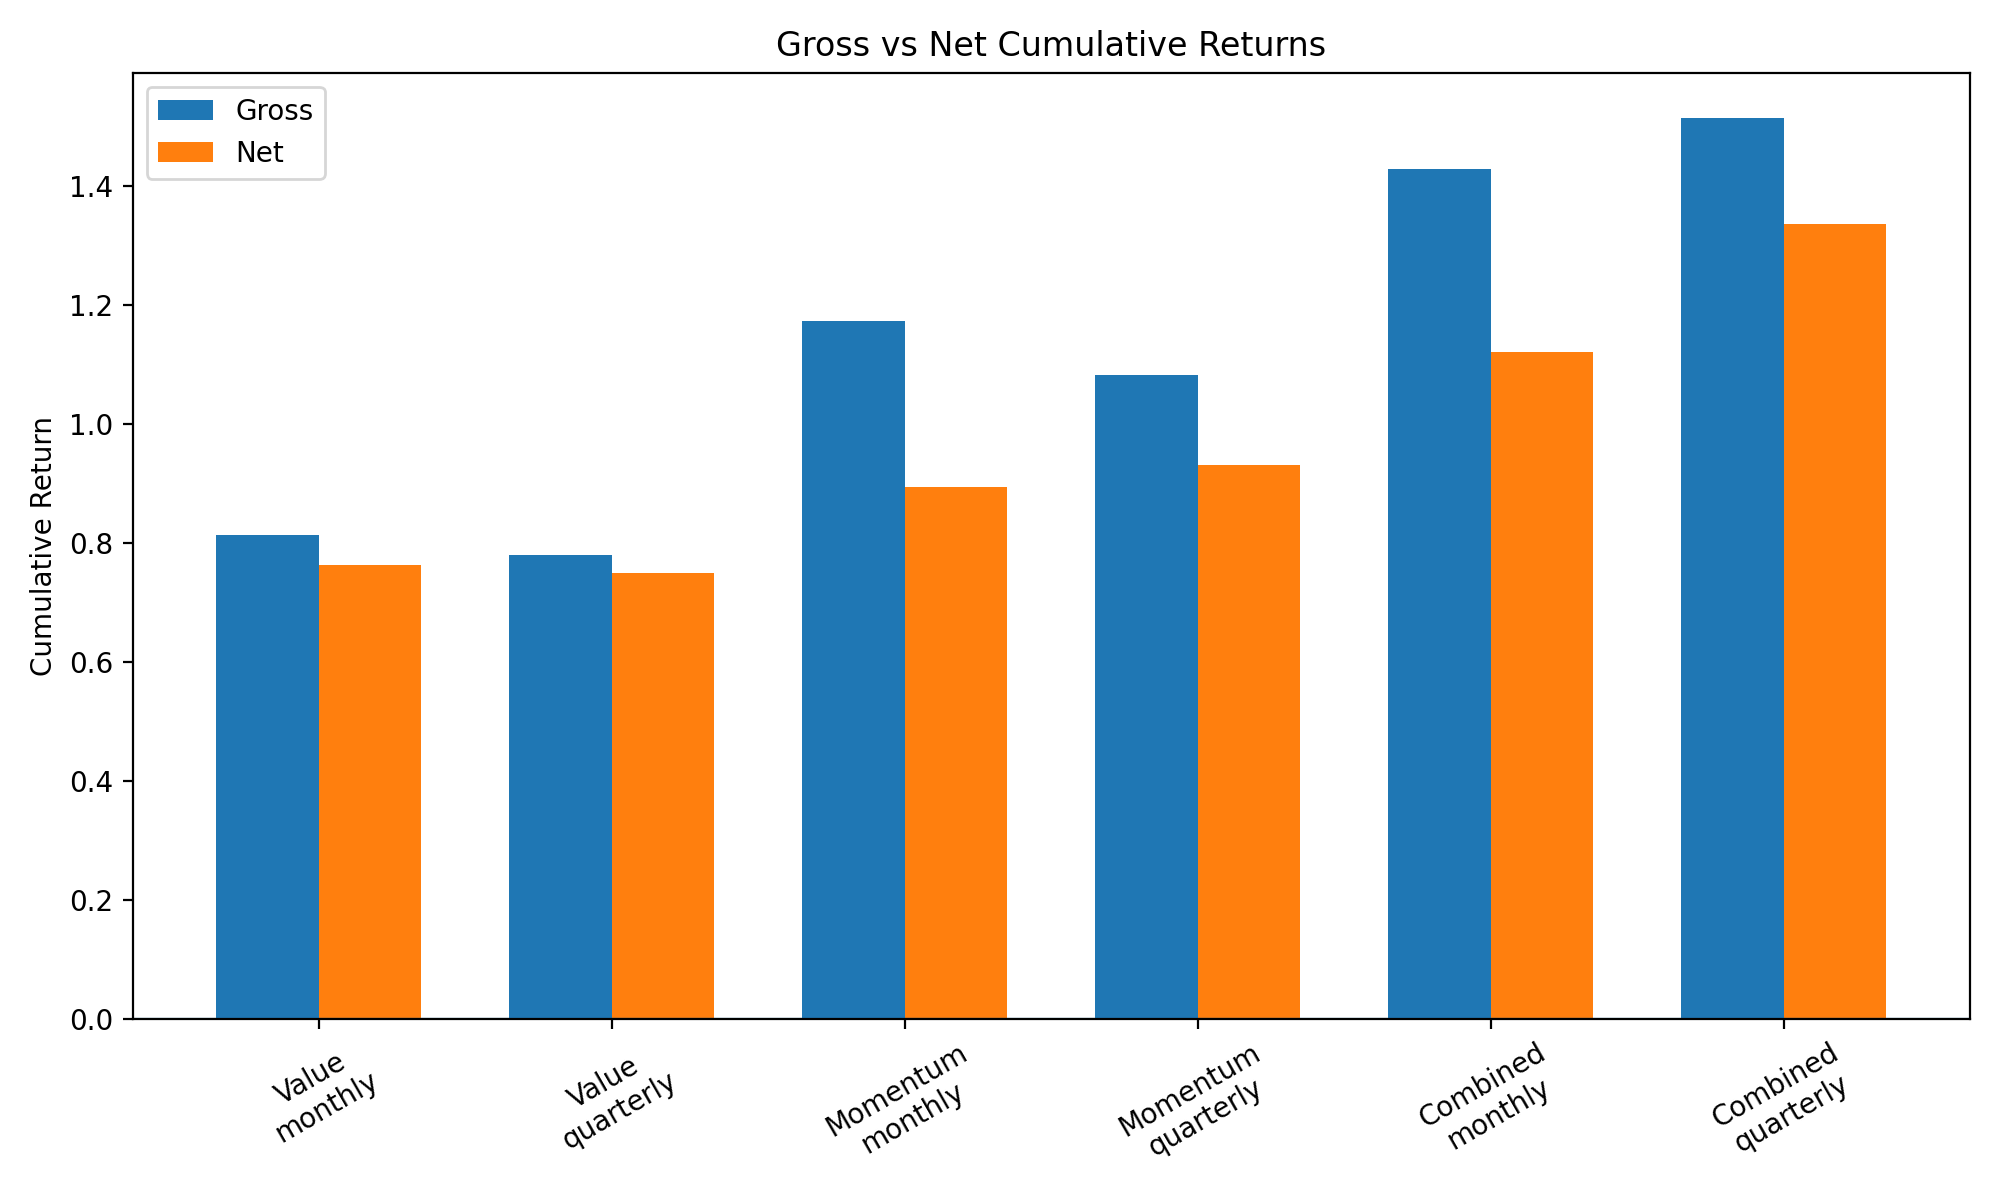

In [9]:
from IPython.display import Image, display

chart_files = [
    "charts/cumulative_returns.png",
    "charts/drawdowns.png",
    "charts/rolling_sharpe.png",
    "charts/turnover.png",
    "charts/cost_drag.png",
]

for path in chart_files:
    print(path)
    display(Image(filename=path))

## Findings

1. Value has substantially lower turnover than Momentum and Combined.

2. The gap between gross and net returns is much larger for the higher-turnover strategies.

3. Quarterly rebalancing produces lower turnover and lower transaction cost drag than monthly rebalancing.

4. Filtering out less liquid securities can materially change strategy performance, especially for the Combined strategy.


## Limitations

1. Transaction costs are modeled rather than directly observed.
2. The backtest covers the available 2018–2024 sample and therefore may not represent future market conditions.